Let we work on with the regression Problem 


In [2]:
#IMPORTING basic packages fro handling the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scp

#import packages for preprocessing the data 

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

# Building the pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# importing the Model Algorithms

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor

# Packages for ensemble learning method 

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.ensemble import StackingRegressor
import xgboost
import catboost
import lightgbm

#Packages for eveluating the model 

from sklearn.metrics import mean_absolute_error,mean_squared_error

#train test split

from sklearn.model_selection import train_test_split

# Crosss validation packages 

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold


In [3]:
raw_data=pd.read_csv("boston.csv")

In [4]:
raw_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
raw_data.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [6]:
raw_data.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Detecting the Outliers

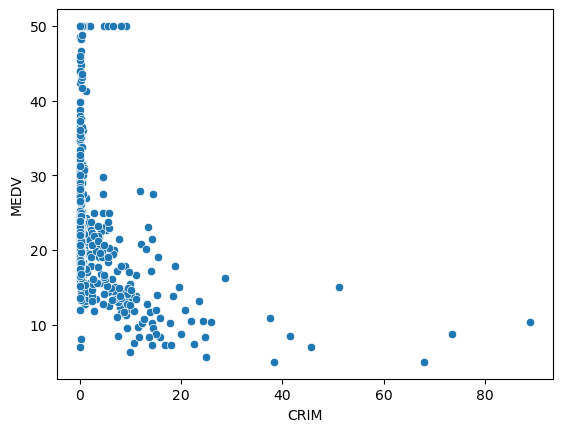

In [8]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='CRIM',y='MEDV')
plt.show()

In [10]:
crim_remove=raw_data[raw_data["CRIM"]>=34]

In [11]:
crim_remove

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
380,88.9762,0.0,18.1,0,0.671,6.968,91.9,1.4165,24,666.0,20.2,396.90,17.21,10.4
398,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666.0,20.2,396.90,30.59,5.0
404,41.5292,0.0,18.1,0,0.693,5.531,85.4,1.6074,24,666.0,20.2,329.46,27.38,8.5
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666.0,20.2,384.97,22.98,5.0
410,51.1358,0.0,18.1,0,0.597,5.757,100.0,1.4130,24,666.0,20.2,2.60,10.11,15.0
414,45.7461,0.0,18.1,0,0.693,4.519,100.0,1.6582,24,666.0,20.2,88.27,36.98,7.0
418,73.5341,0.0,18.1,0,0.679,5.957,100.0,1.8026,24,666.0,20.2,16.45,20.62,8.8
427,37.6619,0.0,18.1,0,0.679,6.202,78.7,1.8629,24,666.0,20.2,18.82,14.52,10.9


380,398,404,405,410,414,418,427

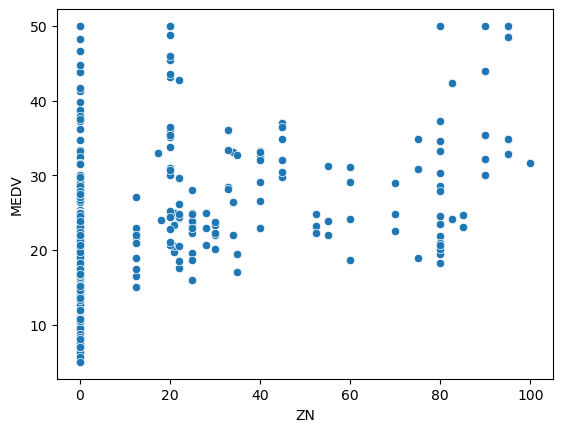

In [12]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='ZN',y='MEDV')
plt.show()

In [14]:
raw_data['ZN'].describe()

count    506.000000
mean      11.363636
std       23.322453
min        0.000000
25%        0.000000
50%        0.000000
75%       12.500000
max      100.000000
Name: ZN, dtype: float64

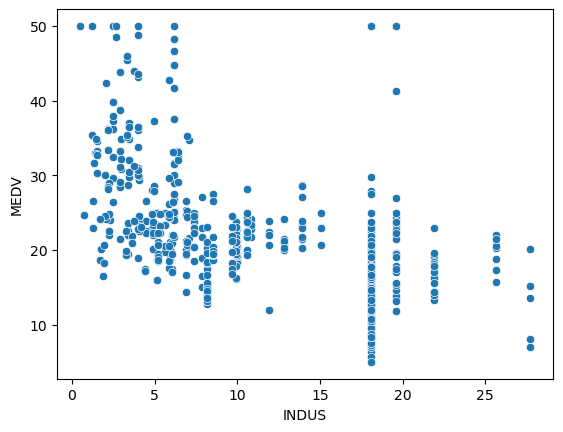

In [17]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='INDUS',y='MEDV')
plt.show()

In [21]:
ind_remove=raw_data[(raw_data["INDUS"]>=15) & (raw_data["MEDV"]>30)]
ind_remove

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
157,1.22358,0.0,19.58,0,0.605,6.943,97.4,1.8773,5,403.0,14.7,363.43,4.59,41.3
161,1.46336,0.0,19.58,0,0.605,7.489,90.8,1.9709,5,403.0,14.7,374.43,1.73,50.0
162,1.83377,0.0,19.58,1,0.605,7.802,98.2,2.0407,5,403.0,14.7,389.61,1.92,50.0
163,1.51902,0.0,19.58,1,0.605,8.375,93.9,2.1620,5,403.0,14.7,388.45,3.32,50.0
166,2.01019,0.0,19.58,0,0.605,7.929,96.2,2.0459,5,403.0,14.7,369.30,3.70,50.0
368,4.89822,0.0,18.10,0,0.631,4.970,100.0,1.3325,24,666.0,20.2,375.52,3.26,50.0
369,5.66998,0.0,18.10,1,0.631,6.683,96.8,1.3567,24,666.0,20.2,375.33,3.73,50.0
370,6.53876,0.0,18.10,1,0.631,7.016,97.5,1.2024,24,666.0,20.2,392.05,2.96,50.0
371,9.23230,0.0,18.10,0,0.631,6.216,100.0,1.1691,24,666.0,20.2,366.15,9.53,50.0
372,8.26725,0.0,18.10,1,0.668,5.875,89.6,1.1296,24,666.0,20.2,347.88,8.88,50.0


157,161,162,163,166,368,369,370,371,372,364,365,367,380,398,404,405,410,414,418,427

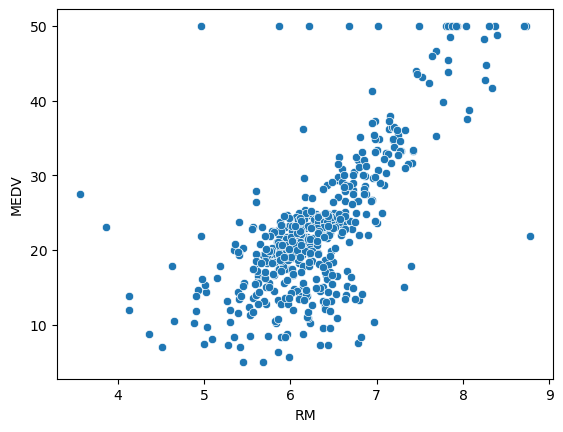

In [25]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='RM',y='MEDV')
plt.show()

In [28]:
rm_remove=raw_data[(raw_data["RM"]<4) & (raw_data["MEDV"]<30)]
rm_remove

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
365,4.55587,0.0,18.1,0,0.718,3.561,87.9,1.6132,24,666.0,20.2,354.70,7.12,27.5
367,13.52220,0.0,18.1,0,0.631,3.863,100.0,1.5106,24,666.0,20.2,131.42,13.33,23.1


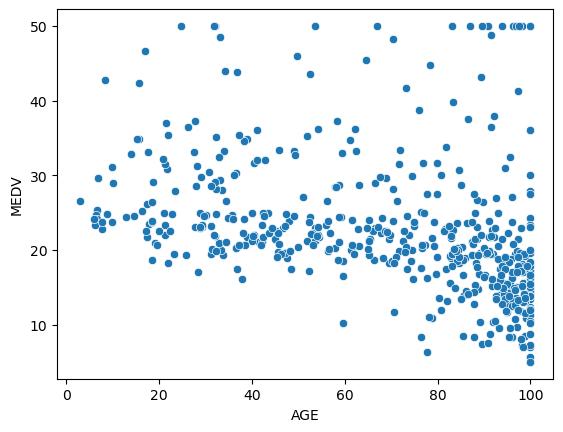

In [29]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='AGE',y='MEDV')
plt.show()

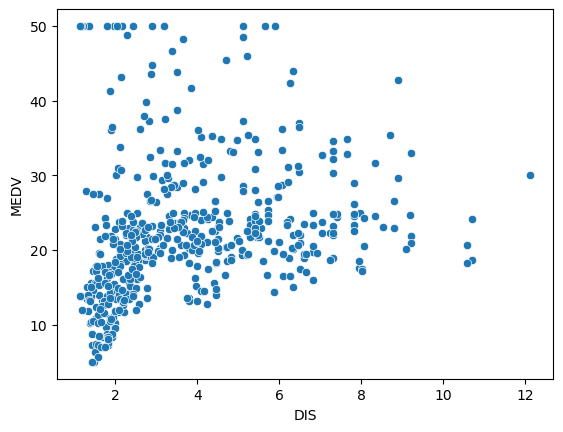

In [30]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='DIS',y='MEDV')
plt.show()

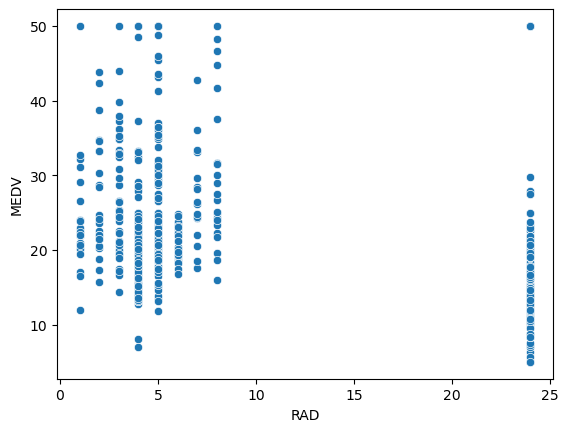

In [31]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='RAD',y='MEDV')
plt.show()

In [33]:
rad_remove=raw_data[(raw_data["RAD"]>20) & (raw_data["MEDV"]>40)]
rad_remove

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
368,4.89822,0.0,18.1,0,0.631,4.970,100.0,1.3325,24,666.0,20.2,375.52,3.26,50.0
369,5.66998,0.0,18.1,1,0.631,6.683,96.8,1.3567,24,666.0,20.2,375.33,3.73,50.0
370,6.53876,0.0,18.1,1,0.631,7.016,97.5,1.2024,24,666.0,20.2,392.05,2.96,50.0
371,9.23230,0.0,18.1,0,0.631,6.216,100.0,1.1691,24,666.0,20.2,366.15,9.53,50.0
372,8.26725,0.0,18.1,1,0.668,5.875,89.6,1.1296,24,666.0,20.2,347.88,8.88,50.0


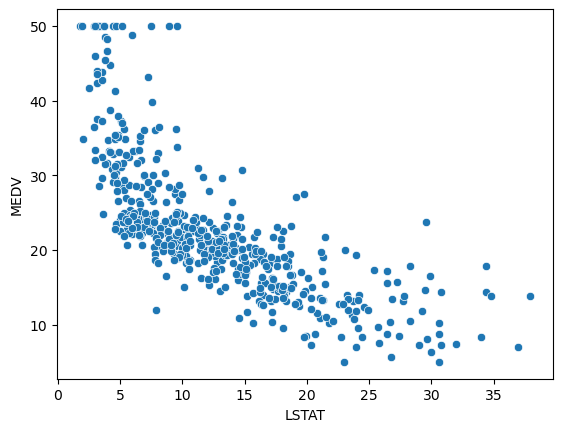

In [37]:
plt_=plt.Figure(figsize=(4,6))
sns.scatterplot(data=raw_data,x='LSTAT',y='MEDV')
plt.show()

In [43]:
raw_data=raw_data.drop(columns='ID')

In [46]:
raw_data["ID"]=range(0,len(raw_data))

In [47]:
raw_data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,ID
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,1
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,2
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,3
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4,501
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6,502
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9,503
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0,504


In [ ]:
# Removing outliers
array_outlier=[157,161,162,163,166,368,369,370,371,372,364,365,367,380,398,404,405,410,414,418,427]
raw= raw_data.drop(array_outlier)

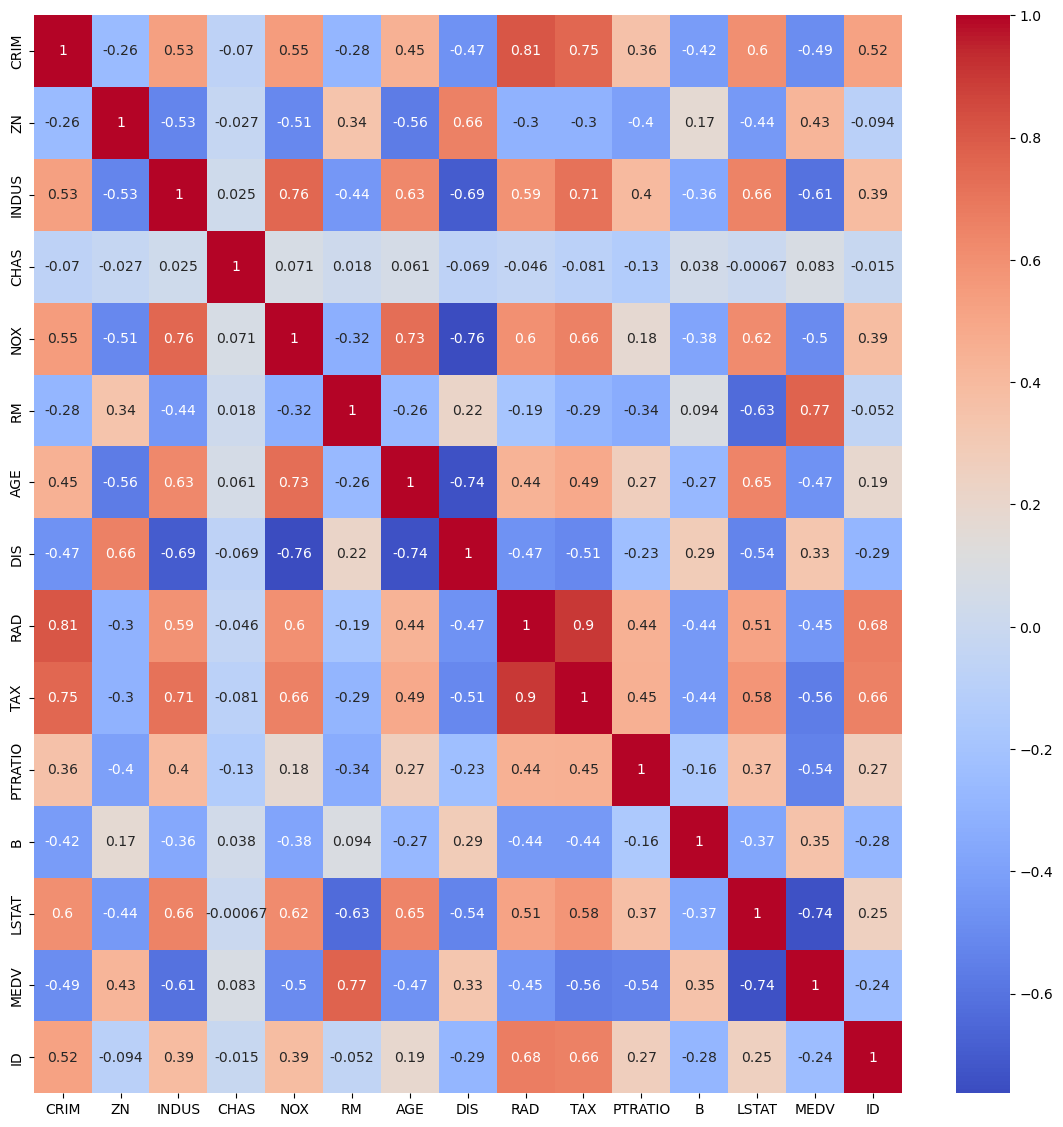

In [52]:
corr_num=raw.corr(numeric_only=True)
plt.figure(figsize=(14,14))
sns.heatmap(corr_num,cmap="coolwarm",annot=True)
plt.show()

drop highly correalted feature 

In [54]:
data=raw
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,ID
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,1
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,2
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,3
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4,501
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6,502
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9,503
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0,504


In [ ]:
data=data.drop(columns='TAX')


In [59]:
data=data.drop(columns='ID')


In [61]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,18.7,396.90,5.33,36.2


In [63]:
y_data=data["MEDV"]
y_data.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

In [ ]:
data=data.drop(columns='MEDV')


KeyError: "['MEDV'] not found in axis"

In [67]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT
count,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000
mean,2.720368,11.855670,10.820021,0.059794,0.550502,6.285470,67.446804,3.889279,9.119588,18.436701,359.298701,12.685979
std,5.110525,23.700041,6.831299,0.237349,0.116258,0.659234,28.183020,2.099518,8.473715,2.154923,87.647632,6.980301
min,0.006320,0.000000,0.460000,0.000000,0.385000,4.138000,2.900000,1.137000,1.000000,12.600000,0.320000,1.980000
25%,0.078960,0.000000,5.130000,0.000000,0.448000,5.889000,42.600000,2.170500,4.000000,17.400000,376.750000,7.190000
50%,0.224890,0.000000,8.560000,0.000000,0.524000,6.209000,74.900000,3.363300,5.000000,18.900000,391.990000,11.450000
75%,2.635480,20.000000,18.100000,0.000000,0.624000,6.606000,93.400000,5.287300,8.000000,20.200000,396.300000,16.940000
max,28.655800,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,12.126500,24.000000,22.000000,396.900000,37.970000


Standard Scaling of the data

In [68]:
std_scaling=StandardScaler()
data=std_scaling.fit_transform(data)

In [70]:
data=pd.DataFrame(data,columns=["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","PTRATIO","B","LSTAT"])

In [72]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT
count,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02,4.850000e+02
mean,-2.930073e-17,5.127628e-17,3.223080e-16,-2.197555e-17,2.637066e-16,1.622528e-15,3.369584e-16,-5.860146e-17,2.344059e-16,1.289232e-15,2.051051e-16,-7.325183e-17
std,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00,1.001033e+00
min,-5.316186e-01,-5.007549e-01,-1.518118e+00,-2.521834e-01,-1.425044e+00,-3.260887e+00,-2.292638e+00,-1.312264e+00,-9.591981e-01,-2.711340e+00,-4.099932e+00,-1.535326e+00
25%,-5.173901e-01,-5.007549e-01,-8.337939e-01,-2.521834e-01,-8.825879e-01,-6.020313e-01,-8.825335e-01,-8.194994e-01,-6.047965e-01,-4.815818e-01,1.993131e-01,-7.881687e-01
50%,-4.888058e-01,-5.007549e-01,-3.311748e-01,-2.521834e-01,-2.281971e-01,-1.161182e-01,2.647300e-01,-2.507824e-01,-4.866627e-01,2.152176e-01,3.733707e-01,-1.772496e-01
75%,-1.662748e-02,3.439968e-01,1.066780e+00,-2.521834e-01,6.328436e-01,4.867178e-01,9.218314e-01,6.665645e-01,-1.322612e-01,8.191104e-01,4.225956e-01,6.100616e-01
max,5.080146e+00,3.723004e+00,2.479389e+00,3.965367e+00,2.759614e+00,3.704374e+00,1.156257e+00,3.927437e+00,1.757880e+00,1.655270e+00,4.294483e-01,3.625937e+00


Let move on building the model 

In [75]:
X_train,X_test,y_train,y_test=train_test_split(data,y_data,test_size=0.3,random_state=42)

LR

In [76]:
LR=LinearRegression()
lr_model=LR.fit(X_train,y_train)
lr_model.score(X_test,y_test)

0.7202406355860977

In [ ]:
cv_lr=cross_val_score(estimator=LR,X=X_train,y=y_train,cv=6,n_jobs=-1)

cv_lr.mean()

np.float64(0.8181605002753298)

Ridge Regrassion

In [90]:
RR=Ridge()
rr_model=RR.fit(X_train,y_train)
rr_model.score(X_test,y_test)

0.7206787378703354

In [89]:
cv_rr=cross_val_score(estimator=RR,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_rr.mean()

np.float64(0.8182387312772565)

In [105]:
RR_param={
    "alpha":[0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
grid_RR=GridSearchCV(estimator=RR,param_grid=RR_param,cv=5,n_jobs=-1)
grid_RR_model=grid_RR.fit(X_train,y_train)
grid_RR_model.score(X_test,y_test)

0.7233184707410862

In [103]:
grid_RR_model.best_estimator_

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


Lasso


In [91]:
LASS=Lasso()
lass_model=LASS.fit(X_train,y_train)
lass_model.score(X_test,y_test)

0.6969431499359515

In [93]:
cv_lass=cross_val_score(estimator=LASS,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_lass.mean()

np.float64(0.7574274024880867)

In [109]:
LASS_param={
    "alpha": [
        0.0001,
        0.001,
        0.01,
        0.05,
        0.1,
        0.2,
        0.5,
        1,
        2,
        5,
        10
    ]
}
grid_LASS=GridSearchCV(estimator=LASS,param_grid=LASS_param,cv=9,n_jobs=-1)
grid_LASS_model=grid_LASS.fit(X_train,y_train)
grid_LASS_model.score(X_test,y_test)

0.7203510551425822

In [142]:
grid_LASS_model.best_estimator_

,alpha,0.001
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Elastic Net Reg

In [96]:
ENR=ElasticNet()
enr_model=ENR.fit(X_train,y_train)
enr_model.score(X_test,y_test)

0.677724757196916

In [97]:
cv_enr=cross_val_score(estimator=ENR,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_enr.mean()

np.float64(0.7390140889256308)

In [111]:
    

ENR_param={
    "alpha": np.logspace(-4, 1, 25),
    "l1_ratio": np.linspace(0.05, 0.95, 10)

}
grid_ENR=GridSearchCV(estimator=ENR,param_grid=ENR_param,cv=3,n_jobs=-1)
grid_ENR_model=grid_ENR.fit(X_train,y_train)
grid_ENR_model.score(X_test,y_test)

0.7225502073422092

In [143]:
grid_ENR_model.best_estimator_

,alpha,np.float64(0....3417814876617)
,l1_ratio,np.float64(0.05)
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


rNADOM fOREST

In [116]:
RF=RandomForestRegressor()
rf_model=RF.fit(X_train,y_train)
rf_model.score(X_test,y_test)

0.8784867724660904

In [118]:
cv_rf=cross_val_score(estimator=RF,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_rf.mean()

np.float64(0.8666229872651208)

In [120]:
    

RF_param={
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.6, 0.8, 1.0]

}
grid_RF=GridSearchCV(estimator=RF,param_grid=RF_param,cv=3,n_jobs=-1)
grid_RF_model=grid_RF.fit(X_train,y_train)
grid_RF_model.score(X_test,y_test)

0.8782160152147198

In [141]:
grid_RF_model.best_estimator_

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


KNN FOR REGRESSION

In [119]:
from sklearn.neighbors import KNeighborsRegressor

In [121]:
KNNR=KNeighborsRegressor()
knnr_model=KNNR.fit(X_train,y_train)
knnr_model.score(X_test,y_test)

0.8037841910506109

In [122]:
cv_knnr=cross_val_score(estimator=KNNR,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_knnr.mean()

np.float64(0.8115998519790057)

Gradient BOOSTIN reg

In [124]:
GBR=GradientBoostingRegressor()
gbr_model=GBR.fit(X_train,y_train)
gbr_model.score(X_test,y_test)


0.8897991120036653

In [125]:
cv_gbr=cross_val_score(estimator=GBR,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_gbr.mean()

np.float64(0.8895924435748235)

In [126]:
GBR_param={
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 1.0]

}
grid_GBR=GridSearchCV(estimator=GBR,param_grid=GBR_param,cv=3,n_jobs=-1)
grid_GBR_model=grid_GBR.fit(X_train,y_train)
grid_GBR_model.score(X_test,y_test)

0.8850489591894469

In [140]:
grid_GBR_model.best_estimator_

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


Decesion tree

In [129]:
DT=DecisionTreeRegressor()
dt_model=DT.fit(X_train,y_train)
dt_model.score(X_test,y_test)

0.8157444080657604

In [130]:
cv_dt=cross_val_score(estimator=DT,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_dt.mean()

np.float64(0.7580720796810207)

EXtra tree classifier

In [135]:
ETR=ExtraTreesRegressor()
etc_model=ETR.fit(X_train,y_train)
etc_model.score(X_test,y_test)

0.8876390950216476

In [136]:
cv_etr=cross_val_score(estimator=ETR,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_etr.mean()

np.float64(0.8836763874979724)

In [137]:
ETR_param={
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.6, 0.8, 1.0]

}
grid_ETR=GridSearchCV(estimator=ETR,param_grid=ETR_param,cv=3,n_jobs=-1)
grid_ETR_model=grid_ETR.fit(X_train,y_train)
grid_ETR_model.score(X_test,y_test)

0.8837562112916608

In [139]:
grid_ETR_model.best_estimator_

,n_estimators,500
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


Voting Regression

In [152]:
VR=VotingRegressor(estimators=[("GBR",GBR),("RF",RF),("ETR",ETR)])
vr_model=VR.fit(X_train,y_train)
vr_model.score(X_test,y_test)

0.8929666623030995

Stacking Regression 

In [145]:

base_models = [
    ("ridge", Ridge(alpha=10)),
    ("lasso", Lasso(alpha=0.001, max_iter=20000)),
    ("elastic", ElasticNet(alpha=0.01, l1_ratio=0.05, max_iter=20000)),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        max_features=0.6
    )),
    ("gbr", GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=2,
            subsample=0.8,
            min_samples_split=5,
            min_samples_leaf=2
        )),
    ("etr", ExtraTreesRegressor(
        n_estimators=500,
        max_depth=50,
        max_features=0.6
    ))
]
SR=StackingRegressor(estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1)
sr_model=SR.fit(X_train,y_train)
sr_model.score(X_test,y_test)

0.8873504512265211

At final voting regressor leads to the highes accuracy of 0.9(0.892)